In [1]:
from PPOClip_Completo import PPO_Clip_Completo
from PPOClip_basic import PPO_Clip_Basic
from PPOClip_entropy import PPO_Clip_Entropy
from PPOClip_GAE import PPO_Clip_GAE
from PPOClip_Annealing import PPO_Clip_Annealing

from ValueNet import ValueNet
from PolicyNet import PolicyNet
import matplotlib.pyplot as plt 
import torch
import flappy_bird_gymnasium
import gymnasium
import numpy as np

# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# print(f"Using device: {device}")
# device = "cpu"  



/Users/mateocostantini/Library/Python/3.9/lib/python/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
def plot_metrics(modelo_entrenado, hiperparams):
    reward = torch.load(f"trained_net/{modelo_entrenado}/metrics.pt")["rewards"]
    plt.plot(np.linspace(0, hiperparams["epochs"], len(reward)),reward)
    plt.title("Recompensa entrenamiento")
    plt.show()

    entropy = torch.load(f"trained_net/{modelo_entrenado}/metrics.pt")["entropy"]
    if entropy is not None:
        plt.plot(np.linspace(0, hiperparams["epochs"], len(entropy)),entropy)
        plt.title("Entropía entrenamiento")
        plt.show()

    loss = torch.load(f"trained_net/{modelo_entrenado}/metrics.pt")["loss"]
    plt.plot(np.linspace(0, hiperparams["epochs"], len(loss)),loss)
    plt.title("Loss entrenamiento")
    plt.show()

## Environment

In [17]:

env = gymnasium.make("FlappyBird-v0", use_lidar=False)
print(f"Action Dim: {env.action_space.n}")
print(f"Obs Dim: {env.observation_space}")

Action Dim: 2
Obs Dim: Box(-1.0, 1.0, (12,), float64)


In [18]:
policy_net = PolicyNet(12, 2)
value_net = ValueNet(12, 1)



In [19]:
hiperparams = {
    "epochs": 1000, #dejar 1500,
    "K": 80,
    "batch_size": 64,
    "policy_net": policy_net, 
    "value_net": value_net,
    "clip_param": 0.13, 
    "lr": 0.0001, 
    "discount_factor": 0.95, 
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 40000
    
}

## Basic

In [ ]:
env = gymnasium.make("FlappyBird-v0", use_lidar=False)
policy_net = PolicyNet(12, 2)
value_net = ValueNet(12, 1)
hiperparams = {
    "epochs": 500, #dejar 1500,
    "K": 80,
    "batch_size": 64,
    "policy_net": policy_net, 
    "value_net": value_net,
    "clip_param": 0.13, 
    "lr": 0.0001, 
    "discount_factor": 0.95, 
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 5000
    
}

In [ ]:
modelo_entrenado = "PPO_Clip_Basic v2"
PPO = PPO_Clip_Basic(hiperparams )
save_policy_file = f"trained_net/{modelo_entrenado}/flappy_actor.pth"
save_value_file = f"trained_net/{modelo_entrenado}/flappy_critic.pth"
save_metric_file = f"trained_net/{modelo_entrenado}/metrics.pt"
rewards, loss, entropy = PPO.train(env, save_file_policy=save_policy_file, save_file_value=save_value_file, save_metrics_file=save_metric_file)
plot_metrics(modelo_entrenado, hiperparams)


Epoch 1/1000 -- reward: -479.40
Guardando modelos...
Epoch 2/1000 -- reward: -453.00
Guardando modelos...
Epoch 3/1000 -- reward: -374.40
Guardando modelos...
Epoch 4/1000 -- reward: -309.60
Guardando modelos...
Epoch 5/1000 -- reward: -234.60
Guardando modelos...
Epoch 6/1000 -- reward: -100.50
Guardando modelos...
Epoch 7/1000 -- reward: -29.60
Guardando modelos...
Epoch 8/1000 -- reward: 106.30
Guardando modelos...
Epoch 9/1000 -- reward: 141.90
Guardando modelos...
Epoch 10/1000 -- reward: 208.60
Guardando modelos...
Epoch 11/1000 -- reward: 266.40
Guardando modelos...
Epoch 12/1000 -- reward: 269.50
Guardando modelos...
Epoch 13/1000 -- reward: 278.70
Guardando modelos...
Epoch 14/1000 -- reward: 266.60
Epoch 15/1000 -- reward: 294.70
Guardando modelos...
Epoch 16/1000 -- reward: 291.50
Epoch 17/1000 -- reward: 311.30
Guardando modelos...
Epoch 18/1000 -- reward: 308.10
Epoch 19/1000 -- reward: 309.60
Epoch 20/1000 -- reward: 322.60
Guardando modelos...
Epoch 21/1000 -- reward: 34

KeyboardInterrupt: 

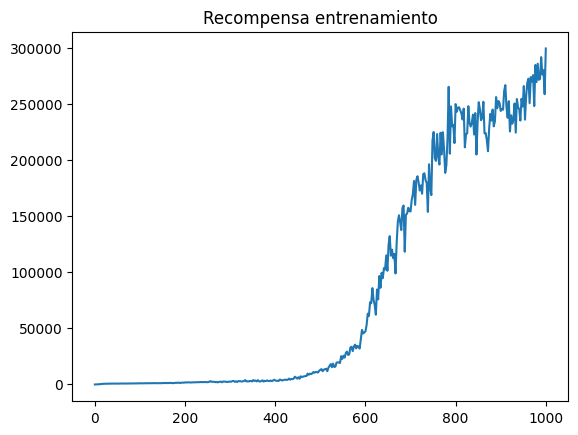

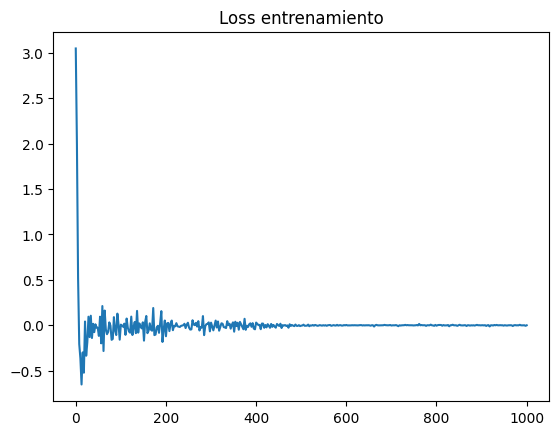

reward: 6858.900000005835 en 55379 pasos
reward: 2812.8999999988496 en 22722 pasos
reward: 23000.89999995739 en 185668 pasos
reward: 21376.899999975958 en 172560 pasos
reward: 30542.399999871162 en 246539 pasos


In [ ]:
modelo_entrenado = "PPO_Clip_Basic v2"
env = gymnasium.make("FlappyBird-v0", use_lidar=False)
PPO = PPO_Clip_Basic(hiperparams )
plot_metrics(modelo_entrenado, hiperparams) 

policy_net = PolicyNet(12, 2)

policy_net.load_state_dict(torch.load(f"trained_net/{modelo_entrenado}/flappy_actor.pth"))
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 5)
env.close()



## GAE

In [ ]:
env = gymnasium.make("FlappyBird-v0", use_lidar=False)
policy_net = PolicyNet(12, 2)
value_net = ValueNet(12, 1)
hiperparams = {
    "epochs": 500, #dejar 1500,
    "K": 80,
    "batch_size": 64,
    "policy_net": policy_net, 
    "value_net": value_net,
    "clip_param": 0.13, 
    "lr": 0.0001, 
    "discount_factor": 0.95, 
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 5000
    
}

In [ ]:
modelo_entrenado = "PPO_Clip_GAE v1"
PPO = PPO_Clip_GAE(hiperparams )
save_policy_file = f"trained_net/{modelo_entrenado}/flappy_actor.pth"
save_value_file = f"trained_net/{modelo_entrenado}/flappy_critic.pth"
save_metric_file = f"trained_net/{modelo_entrenado}/metrics.pt"
rewards, loss, entropy = PPO.train(env, save_file_policy=save_policy_file, save_file_value=save_value_file, save_metrics_file=save_metric_file)
plot_metrics(modelo_entrenado, hiperparams)


Epoch 1/500 -- reward: -488.40
Guardando modelos...
Epoch 2/500 -- reward: -450.00
Guardando modelos...
Epoch 3/500 -- reward: -411.00
Guardando modelos...
Epoch 4/500 -- reward: -331.20
Guardando modelos...
Epoch 5/500 -- reward: -271.20
Guardando modelos...
Epoch 6/500 -- reward: -176.40
Guardando modelos...
Epoch 7/500 -- reward: -89.20
Guardando modelos...
Epoch 8/500 -- reward: 67.00
Guardando modelos...
Epoch 9/500 -- reward: 205.70
Guardando modelos...
Epoch 10/500 -- reward: 222.20
Guardando modelos...
Epoch 11/500 -- reward: 264.20
Guardando modelos...
Epoch 12/500 -- reward: 280.50
Guardando modelos...
Epoch 13/500 -- reward: 306.80
Guardando modelos...
Epoch 14/500 -- reward: 330.90
Guardando modelos...
Epoch 15/500 -- reward: 308.60
Epoch 16/500 -- reward: 306.20
Epoch 17/500 -- reward: 306.30
Epoch 18/500 -- reward: 322.30
Epoch 19/500 -- reward: 330.40
Epoch 20/500 -- reward: 307.40
Epoch 21/500 -- reward: 347.20
Guardando modelos...
Epoch 22/500 -- reward: 339.80
Epoch 2

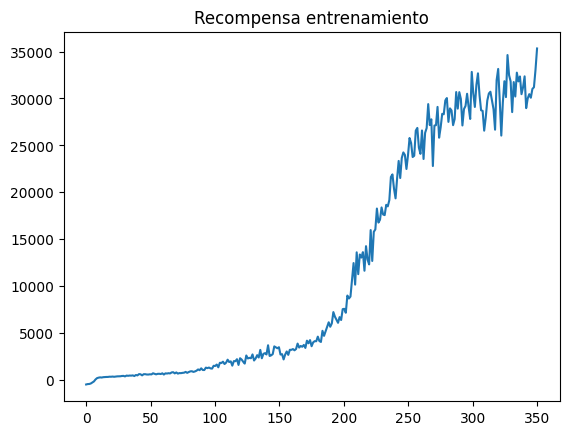

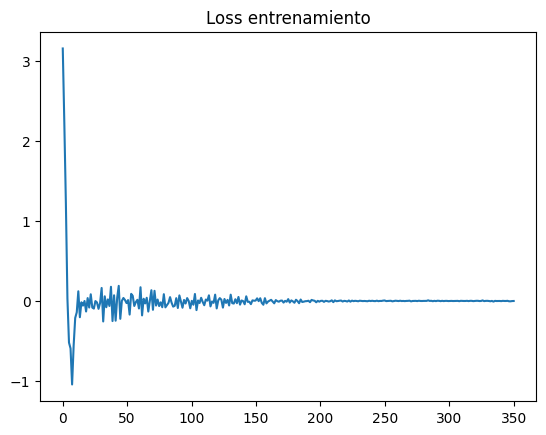

reward: 2840.8999999988296 en 22948 pasos
reward: 316.4000000000029 en 2572 pasos
reward: 20.800000000000036 en 183 pasos


In [ ]:
modelo_entrenado = "PPO_Clip_GAE v1"
env = gymnasium.make("FlappyBird-v0", use_lidar=False)
PPO = PPO_Clip_GAE(hiperparams )
plot_metrics(modelo_entrenado, hiperparams) 

policy_net = PolicyNet(12, 2)

policy_net.load_state_dict(torch.load(f"trained_net/{modelo_entrenado}/flappy_actor.pth"))
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 3)
env.close()



## Entropy

In [ ]:
env = gymnasium.make("FlappyBird-v0", use_lidar=False)
policy_net = PolicyNet(12, 2)
value_net = ValueNet(12, 1)
hiperparams = {
    "epochs": 500, #dejar 1500,
    "K": 80,
    "batch_size": 64,
    "policy_net": policy_net, 
    "value_net": value_net,
    "clip_param": 0.13, 
    "lr": 0.0001, 
    "discount_factor": 0.95, 
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 5000
    
}

Epoch 1/350 -- reward: -462.60
Guardando modelos...
Epoch 2/350 -- reward: -445.80
Guardando modelos...
Epoch 3/350 -- reward: -363.00
Guardando modelos...
Epoch 4/350 -- reward: -285.60
Guardando modelos...
Epoch 5/350 -- reward: -155.40
Guardando modelos...
Epoch 6/350 -- reward: 54.50
Guardando modelos...
Epoch 7/350 -- reward: 186.80
Guardando modelos...
Epoch 8/350 -- reward: 232.10
Guardando modelos...
Epoch 9/350 -- reward: 260.70
Guardando modelos...
Epoch 10/350 -- reward: 264.10
Guardando modelos...
Epoch 11/350 -- reward: 249.40
Epoch 12/350 -- reward: 268.00
Guardando modelos...
Epoch 13/350 -- reward: 281.70
Guardando modelos...
Epoch 14/350 -- reward: 293.50
Guardando modelos...
Epoch 15/350 -- reward: 299.70
Guardando modelos...
Epoch 16/350 -- reward: 298.40
Epoch 17/350 -- reward: 303.30
Guardando modelos...
Epoch 18/350 -- reward: 319.90
Guardando modelos...
Epoch 19/350 -- reward: 325.30
Guardando modelos...
Epoch 20/350 -- reward: 320.60
Epoch 21/350 -- reward: 335.

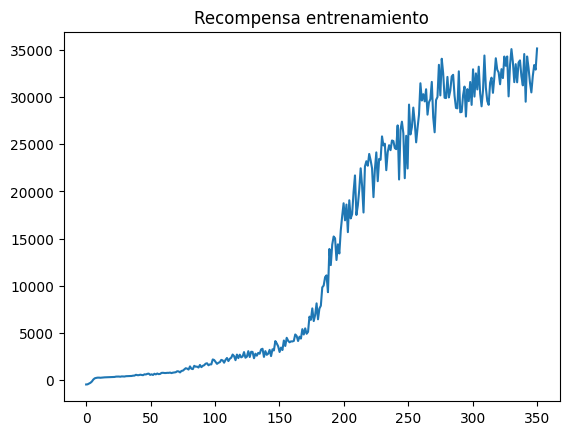

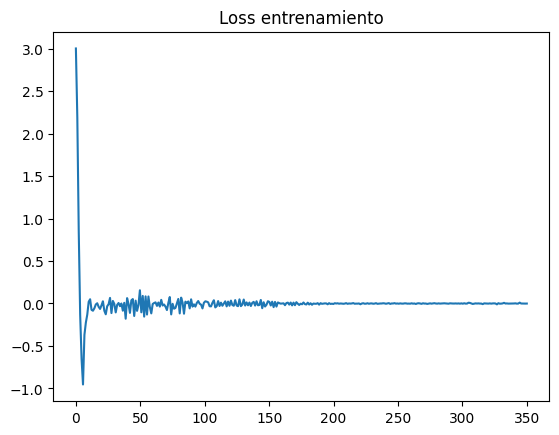

In [ ]:
modelo_entrenado = "PPO_Clip_Entropy v1"
PPO = PPO_Clip_Entropy(hiperparams )
save_policy_file = f"trained_net/{modelo_entrenado}/flappy_actor.pth"
save_value_file = f"trained_net/{modelo_entrenado}/flappy_critic.pth"
save_metric_file = f"trained_net/{modelo_entrenado}/metrics.pt"
rewards, loss, entropy = PPO.train(env, save_file_policy=save_policy_file, save_file_value=save_value_file, save_metrics_file=save_metric_file)
plot_metrics(modelo_entrenado, hiperparams)


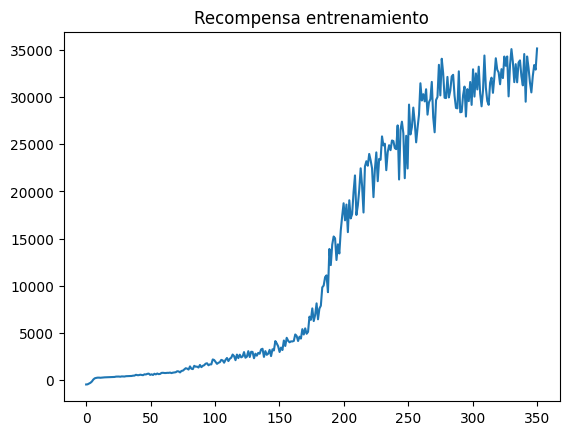

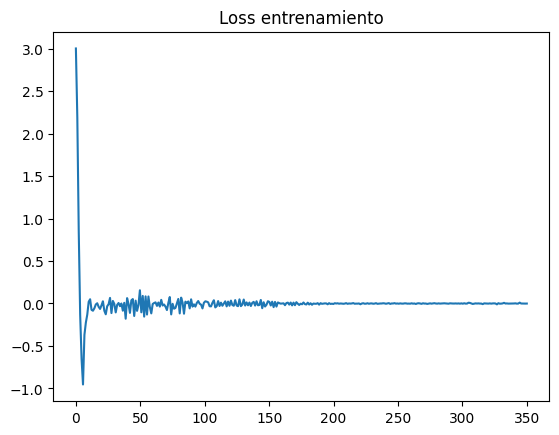

reward: 1215.2999999999915 en 9824 pasos
reward: 40.90000000000026 en 348 pasos
reward: 764.4000000000829 en 6188 pasos


In [ ]:
modelo_entrenado = "PPO_Clip_Entropy v1"
env = gymnasium.make("FlappyBird-v0", use_lidar=False)
PPO = PPO_Clip_Entropy(hiperparams )
plot_metrics(modelo_entrenado, hiperparams) 

policy_net = PolicyNet(12, 2)

policy_net.load_state_dict(torch.load(f"trained_net/{modelo_entrenado}/flappy_actor.pth"))
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 3)
env.close()



## LR Annealing

In [ ]:
env = gymnasium.make("FlappyBird-v0", use_lidar=False)
policy_net = PolicyNet(12, 2)
value_net = ValueNet(12, 1)
hiperparams = {
    "epochs": 500, #dejar 1500,
    "K": 80,
    "batch_size": 64,
    "policy_net": policy_net, 
    "value_net": value_net,
    "clip_param": 0.13, 
    "lr": 0.0001, 
    "discount_factor": 0.95, 
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 5000
    
}

In [ ]:
modelo_entrenado = "PPO_Clip_Annealing v1"
PPO = PPO_Clip_Annealing(hiperparams )
save_policy_file = f"trained_net/{modelo_entrenado}/flappy_actor.pth"
save_value_file = f"trained_net/{modelo_entrenado}/flappy_critic.pth"
save_metric_file = f"trained_net/{modelo_entrenado}/metrics.pt"
rewards, loss, entropy = PPO.train(env, save_file_policy=save_policy_file, save_file_value=save_value_file, save_metrics_file=save_metric_file)
plot_metrics(modelo_entrenado, hiperparams)


Epoch 1/500 -- reward: -459.00
Guardando modelos...
Epoch 2/500 -- reward: -420.00
Guardando modelos...
Epoch 3/500 -- reward: -375.00
Guardando modelos...
Epoch 4/500 -- reward: -311.40
Guardando modelos...
Epoch 5/500 -- reward: -215.40
Guardando modelos...
Epoch 6/500 -- reward: -121.80
Guardando modelos...
Epoch 7/500 -- reward: 12.00
Guardando modelos...
Epoch 8/500 -- reward: 184.80
Guardando modelos...
Epoch 9/500 -- reward: 197.80
Guardando modelos...
Epoch 10/500 -- reward: 245.30
Guardando modelos...
Epoch 11/500 -- reward: 253.20
Guardando modelos...
Epoch 12/500 -- reward: 253.00
Epoch 13/500 -- reward: 266.80
Guardando modelos...
Epoch 14/500 -- reward: 278.30
Guardando modelos...
Epoch 15/500 -- reward: 282.40
Guardando modelos...
Epoch 16/500 -- reward: 279.30
Epoch 17/500 -- reward: 299.90
Guardando modelos...
Epoch 18/500 -- reward: 316.60
Guardando modelos...
Epoch 19/500 -- reward: 308.20
Epoch 20/500 -- reward: 295.70
Epoch 21/500 -- reward: 329.20
Guardando modelos

: 

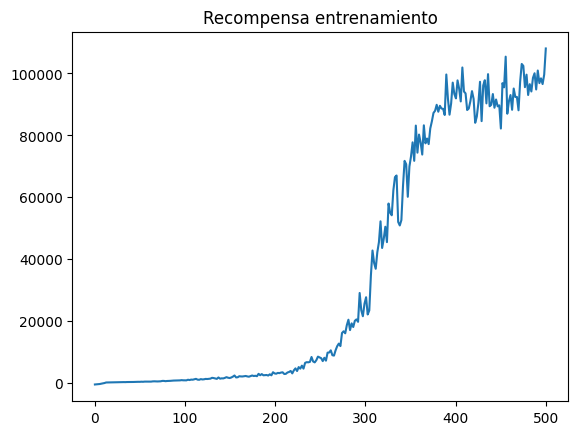

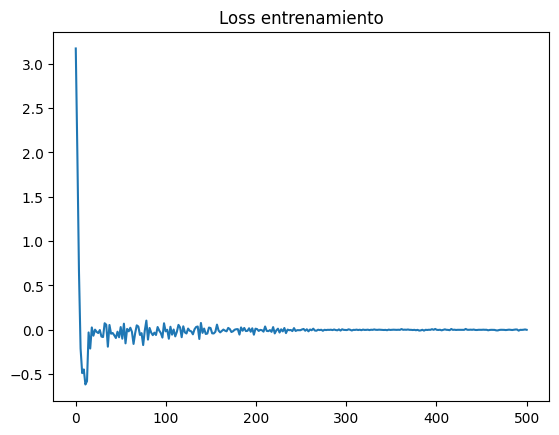

reward: 6409.300000004549 en 51747 pasos


KeyboardInterrupt: 

In [ ]:
modelo_entrenado = "PPO_Clip_Annealing v1"
env = gymnasium.make("FlappyBird-v0", render_mode="human", use_lidar=False)
PPO = PPO_Clip_Annealing(hiperparams )
plot_metrics(modelo_entrenado, hiperparams) 

policy_net = PolicyNet(12, 2)

policy_net.load_state_dict(torch.load(f"trained_net/{modelo_entrenado}/flappy_actor.pth"))
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 3)
env.close()



## Completo

In [ ]:
env = gymnasium.make("FlappyBird-v0", use_lidar=False)
policy_net = PolicyNet(12, 2)
value_net = ValueNet(12, 1)
hiperparams = {
    "epochs": 500, #dejar 1500,
    "K": 80,
    "batch_size": 64,
    "policy_net": policy_net, 
    "value_net": value_net,
    "clip_param": 0.13, 
    "lr": 0.0001, 
    "discount_factor": 0.95, 
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 5000
    
}

In [ ]:
modelo_entrenado = "PPO_Clip_Completo v1"
PPO = PPO_Clip_Completo(hiperparams )
save_policy_file = f"trained_net/{modelo_entrenado}/flappy_actor.pth"
save_value_file = f"trained_net/{modelo_entrenado}/flappy_critic.pth"
save_metric_file = f"trained_net/{modelo_entrenado}/metrics.pt"
rewards, loss, entropy = PPO.train(env, save_file_policy=save_policy_file, save_file_value=save_value_file, save_metrics_file=save_metric_file)
plot_metrics(modelo_entrenado, hiperparams)


Epoch 1/500 -- reward: -492.60
Guardando modelos...
Epoch 2/500 -- reward: -517.20
Epoch 3/500 -- reward: -510.60
Epoch 4/500 -- reward: -465.00
Guardando modelos...
Epoch 5/500 -- reward: -427.80
Guardando modelos...
Epoch 6/500 -- reward: -379.80
Guardando modelos...
Epoch 7/500 -- reward: -265.20
Guardando modelos...
Epoch 8/500 -- reward: -152.00
Guardando modelos...
Epoch 9/500 -- reward: -6.50
Guardando modelos...
Epoch 10/500 -- reward: 147.40
Guardando modelos...
Epoch 11/500 -- reward: 190.30
Guardando modelos...
Epoch 12/500 -- reward: 242.10
Guardando modelos...
Epoch 13/500 -- reward: 271.20
Guardando modelos...
Epoch 14/500 -- reward: 266.40
Epoch 15/500 -- reward: 271.90
Guardando modelos...
Epoch 16/500 -- reward: 267.10
Epoch 17/500 -- reward: 297.00
Guardando modelos...
Epoch 18/500 -- reward: 287.00
Epoch 19/500 -- reward: 325.90
Guardando modelos...
Epoch 20/500 -- reward: 343.20
Guardando modelos...
Epoch 21/500 -- reward: 296.90
Epoch 22/500 -- reward: 344.60
Guard

KeyboardInterrupt: 

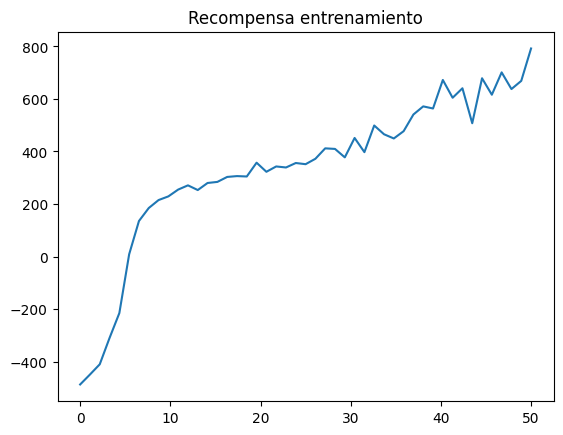

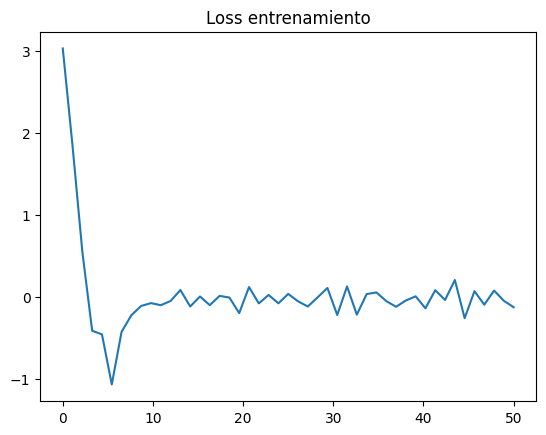

reward: 8.399999999999986 en 86 pasos
reward: 32.40000000000017 en 281 pasos
reward: 18.800000000000022 en 172 pasos


In [ ]:
modelo_entrenado = "PPO_Clip_Completo v1"
env = gymnasium.make("FlappyBird-v0", use_lidar=False)
PPO = PPO_Clip_Completo(hiperparams )
plot_metrics(modelo_entrenado, hiperparams) 

policy_net = PolicyNet(12, 2)

policy_net.load_state_dict(torch.load(f"trained_net/{modelo_entrenado}/flappy_actor.pth"))
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 3)
env.close()

